# 📡 5G Network Quality Forecasting — Deep Learning vs. Tree Ensemble Benchmark

## Motivation

Our initial models (flat features, no lags) had R² ≈ 0.02–0.23 because they
lacked **temporal context**. This rewrite adds proper **hourly lag features**
(the strongest signal in any time series), **rolling statistics**, and
**auxiliary network metrics** (svr1, jitter, congestion) — bringing the total
from 5 to 18 features and enabling R² > 0.9.

## Pipeline Overview

| Step | Description |
|------|-------------|
| **1** | **Data Loading & Feature Engineering** — reconstruct targets, aggregate hourly per zone, create lag1-lag3 + rolling mean, include auxiliary metrics |
| **2** | **Scaling & Sequence Windowing** — strict temporal split, MinMaxScaler, sliding window → 3D tensors (20 columns) |
| **3** | **Train Models** — XGBoost (18 features with lags), CatBoost (500 iters, ordered boosting), LSTM (128→64), 1D CNN (128→64) |
| **4** | **Benchmarking & Visualization** — comparison table (R², MAE, RMSE), actual-vs-predicted overlay |
| **5** | **12-Hour Dashboard Forecast** — autoregressive rolling with lag updates → `metrics/forecast_data.csv` |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, os
from pathlib import Path

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Conv1D, Dense, Dropout,
    Bidirectional, BatchNormalization, GlobalAveragePooling1D,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

# ── Paths & Config ──────────────────────────────────────────────
DATA_DIR    = Path("data")
METRICS_DIR = Path("metrics")
MODELS_DIR  = Path("models")
METRICS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

TARGETS       = ["download_mbps", "avg_latency"]
SEQ_LEN       = 12         # look-back window (hours) for DL models
SPLIT_HOURS   = 48         # last 48 h held out for testing
TOP_N_ZONES   = 5          # zones used for the 12-h dashboard forecast
RANDOM_STATE  = 42

print(f"TensorFlow {tf.__version__}  •  GPU: {tf.config.list_physical_devices('GPU')}")
print(f"Config → SEQ_LEN={SEQ_LEN}, SPLIT_HOURS={SPLIT_HOURS}, TOP_N_ZONES={TOP_N_ZONES}")

TensorFlow 2.20.0  •  GPU: []
Config → SEQ_LEN=12, SPLIT_HOURS=48, TOP_N_ZONES=5


---
## Step 1 — Data Loading & Feature Engineering

### 1a  Load & reconstruct targets
Reconstruct targets from proxies: `log_download` → `expm1` and `avg_latency_lag1`.

### 1b  Aggregate → hourly zone means + grid-fill
Collapse raw rows into `(square_id, date, hour)` blocks via `mean()`. Then **fill
each zone's hourly timeline** (forward-fill gaps) so that lag features represent
true 1-hour-ago values — not values from a random number of hours ago due to data
gaps (44.6% of consecutive observations were >1h apart!).

Without grid-fill: download autocorrelation(lag1) ≈ 0.04. **With grid-fill: 0.80.**

### 1c  Proper temporal lag features
Lags computed on the filled grid, then filtered to real (non-interpolated) rows only.
Cycical temporal + zone encoding from training fold.

In [2]:
# ── 1a: Load cleaned CSV & reconstruct targets ─────────────────
df_raw = pd.read_csv(DATA_DIR / "cleaned_5g_data.csv", low_memory=False)
df_raw["Timestamp"] = pd.to_datetime(df_raw["Timestamp"])

# Reconstruct targets dropped by feature-selection (|r| > 0.95)
df_raw["download_mbps"] = np.expm1(df_raw["log_download"])
df_raw["avg_latency"]   = df_raw["avg_latency_lag1"]

for col in TARGETS:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

df_raw["date"] = df_raw["Timestamp"].dt.date

print(f"Loaded: {len(df_raw):,} rows × {df_raw.shape[1]} columns")
print(f"Unique square_ids: {df_raw['square_id'].nunique()}")
for t in TARGETS:
    print(f"  {t:20s}  mean={df_raw[t].mean():.3f}  nulls={df_raw[t].isna().sum()}")

# ── 1b: Aggregate → hourly zone-level means (targets + auxiliary) ──
# Expanded auxiliary features: network metrics + upload proxy + volatility + TCP
AUX_COLS = [
    "svr1", "jitter", "retransmission_rate", "congestion_indicator",
    "upload_mbps_lag1",          # hourly mean ≈ upload speed in that zone-hour (r=0.41)
    "download_mbps_roll5_std",   # intra-hour download volatility (r=0.39)
    "cwnd_x_speed",              # TCP congestion × GPS speed interaction (r=0.35)
    "CWnd",                      # TCP congestion window size (r=0.16)
    "cwnd_to_latency",           # CWnd / latency ratio (r=0.27)
]
AGG_COLS = TARGETS + AUX_COLS

# Coerce all auxiliary columns to numeric
for c in AUX_COLS:
    df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")

agg_raw = (
    df_raw
    .groupby(["square_id", "date", "hour"])[AGG_COLS]
    .mean()
    .reset_index()
)
agg_raw["date"] = pd.to_datetime(agg_raw["date"])
agg_raw["timestamp"] = agg_raw["date"] + pd.to_timedelta(agg_raw["hour"], unit="h")
agg_raw.dropna(subset=TARGETS, inplace=True)
agg_raw.sort_values(["square_id", "timestamp"], inplace=True)
agg_raw.reset_index(drop=True, inplace=True)

for c in AUX_COLS:
    agg_raw[c].fillna(agg_raw[c].mean(), inplace=True)

print(f"\nAggregated: {len(agg_raw):,} hourly zone-blocks (real measurements)")

# ── Grid-fill per zone (complete hourly timeline + forward-fill) ──
filled_parts: list[pd.DataFrame] = []
for zone, grp in agg_raw.groupby("square_id"):
    rng = pd.date_range(start=grp["timestamp"].min(),
                        end=grp["timestamp"].max(), freq="h")
    full = pd.DataFrame({"timestamp": rng, "square_id": zone})
    full = full.merge(grp.drop(columns=["square_id"]), on="timestamp", how="left")
    full["is_real"] = full[TARGETS[0]].notna()
    full[AGG_COLS] = full[AGG_COLS].ffill()
    full.dropna(subset=TARGETS, inplace=True)
    filled_parts.append(full)

agg_filled = pd.concat(filled_parts, ignore_index=True)
agg_filled.sort_values(["square_id", "timestamp"], inplace=True)
agg_filled.reset_index(drop=True, inplace=True)

n_real = int(agg_filled["is_real"].sum())
print(f"Grid-filled: {len(agg_filled):,} zone-hours "
      f"({n_real:,} real, {len(agg_filled) - n_real:,} interpolated)")

# ── 1c: Per-zone hourly LAG features on the filled grid ────────
LAG_STEPS = 3
for lag in range(1, LAG_STEPS + 1):
    for tgt in TARGETS:
        agg_filled[f"{tgt}_lag{lag}"] = agg_filled.groupby("square_id")[tgt].shift(lag)
    # Also lag upload proxy (upload speed 1–3 hours ago is predictive of download)
    agg_filled[f"upload_lag{lag}"] = (
        agg_filled.groupby("square_id")["upload_mbps_lag1"].shift(lag)
    )

# Per-zone rolling statistics (3-hour window, shift(1) avoids leakage)
for tgt in TARGETS:
    agg_filled[f"{tgt}_rmean3"] = (
        agg_filled.groupby("square_id")[tgt]
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )

# Drop rows where lag features are NaN (first LAG_STEPS rows per zone)
lag_cols = [f"{t}_lag{l}" for t in TARGETS for l in range(1, LAG_STEPS + 1)]
upload_lag_cols = [f"upload_lag{l}" for l in range(1, LAG_STEPS + 1)]
all_lag_cols = lag_cols + upload_lag_cols
agg_filled.dropna(subset=all_lag_cols, inplace=True)
agg_filled.reset_index(drop=True, inplace=True)

# ── 1d: Keep only REAL rows for XGBoost train/test ─────────────
agg_df = agg_filled[agg_filled["is_real"]].copy()
agg_df.reset_index(drop=True, inplace=True)

# Reconstruct date/hour from timestamp
agg_df["date"] = pd.to_datetime(agg_df["timestamp"].dt.date)
agg_df["hour"] = agg_df["timestamp"].dt.hour

print(f"Real rows after lag drop: {len(agg_df):,}")

# ── 1e: Temporal features ──────────────────────────────────────
for frame in [agg_df, agg_filled]:
    frame["hour_sin"]   = np.sin(2 * np.pi * frame["timestamp"].dt.hour / 24)
    frame["hour_cos"]   = np.cos(2 * np.pi * frame["timestamp"].dt.hour / 24)
    frame["is_weekend"] = (frame["timestamp"].dt.dayofweek >= 5).astype(int)

# ── Temporal train/test boundary ────────────────────────────────
cutoff = agg_df["timestamp"].max() - pd.Timedelta(hours=SPLIT_HOURS)
train_mask = agg_df["timestamp"] <= cutoff
test_mask  = agg_df["timestamp"] >  cutoff

# ── Zone-level target encoding (train fold only) ───────────────
zone_enc_dl  = agg_df.loc[train_mask].groupby("square_id")["download_mbps"].mean()
zone_enc_lat = agg_df.loc[train_mask].groupby("square_id")["avg_latency"].mean()
global_mean_dl  = agg_df.loc[train_mask, "download_mbps"].mean()
global_mean_lat = agg_df.loc[train_mask, "avg_latency"].mean()

for frame in [agg_df, agg_filled]:
    frame["zone_mean_dl"]  = frame["square_id"].map(zone_enc_dl).fillna(global_mean_dl)
    frame["zone_mean_lat"] = frame["square_id"].map(zone_enc_lat).fillna(global_mean_lat)

# Zone-level means for auxiliary features (for forecast fallback)
zone_aux_means = {}
for c in AUX_COLS:
    zone_aux_means[c] = agg_df.loc[train_mask].groupby("square_id")[c].mean()

print(f"Train: {train_mask.sum():,}  |  Test: {test_mask.sum():,}  |  Cutoff: {cutoff}")
print(f"Filled grid (for DL windows): {len(agg_filled):,} rows")
agg_df[TARGETS + lag_cols[:3]].describe().round(3)

Loaded: 2,041,013 rows × 66 columns
Unique square_ids: 227
  download_mbps         mean=18.661  nulls=0
  avg_latency           mean=172.550  nulls=8

Aggregated: 4,840 hourly zone-blocks (real measurements)
Grid-filled: 77,459 zone-hours (4,840 real, 72,619 interpolated)
Real rows after lag drop: 4,409
Train: 3,787  |  Test: 622  |  Cutoff: 2022-07-20 03:00:00
Filled grid (for DL windows): 76,797 rows


,download_mbps,avg_latency,download_mbps_lag1,download_mbps_lag2,download_mbps_lag3
count,4409.000,4409.000,4409.000,4409.000,4409.000
mean,20.512,138.092,20.106,20.255,20.471
std,12.978,125.131,12.672,13.590,14.043
min,0.000,22.375,0.000,0.000,0.000
25%,12.225,54.919,12.065,11.667,11.620
50%,18.108,87.349,17.694,17.414,17.503
75%,25.991,177.449,25.436,25.313,25.534
max,74.600,864.333,74.600,74.600,74.600


In [3]:
# ── 2a: Column definitions ──────────────────────────────────────
TREE_FEATURES = [
    # Temporal
    "hour_sin", "hour_cos", "is_weekend",
    # Zone encoding
    "zone_mean_dl", "zone_mean_lat",
    # === Hourly lag features (primary signal for time-series prediction) ===
    "download_mbps_lag1", "download_mbps_lag2", "download_mbps_lag3",
    "avg_latency_lag1", "avg_latency_lag2", "avg_latency_lag3",
    # Upload speed lags (upload correlates with download at r=0.41)
    "upload_lag1", "upload_lag2", "upload_lag3",
    # Rolling mean (no-leakage: shift(1) + rolling(3))
    "download_mbps_rmean3", "avg_latency_rmean3",
    # Auxiliary network metrics (hourly aggregated)
    "svr1", "jitter", "retransmission_rate", "congestion_indicator",
    # New: upload proxy, download volatility, TCP metrics
    "upload_mbps_lag1", "download_mbps_roll5_std", "cwnd_x_speed",
    "CWnd", "cwnd_to_latency",
]
# DL windows include past target values (autoregressive input)
WINDOW_COLS = TREE_FEATURES + TARGETS
TARGET_IDX  = [WINDOW_COLS.index(t) for t in TARGETS]

# ── Tree model data (UNSCALED — trees are scale-invariant) ─────
train_df = agg_df[train_mask].copy()
test_df  = agg_df[test_mask].copy()

X_train_tree = train_df[TREE_FEATURES].values
X_test_tree  = test_df[TREE_FEATURES].values
y_train_tree = train_df[TARGETS].values
y_test_tree  = test_df[TARGETS].values

# ── 2b: MinMaxScaler (fit on TRAIN only, 0-1 range) ───────────
scaler = MinMaxScaler()
scaler.fit(train_df[WINDOW_COLS])

# Scale real rows for reference
agg_scaled = agg_df.copy()
agg_scaled[WINDOW_COLS] = scaler.transform(agg_df[WINDOW_COLS])

# Scale the FILLED grid for DL windowing (consecutive hourly sequences)
agg_filled_scaled = agg_filled.copy()
agg_filled_scaled[WINDOW_COLS] = scaler.transform(agg_filled[WINDOW_COLS])

# Save scaler stats for inverse transform later
target_min   = scaler.data_min_[TARGET_IDX]
target_range = scaler.data_range_[TARGET_IDX]

print("MinMaxScaler fit on training fold (0-1 range).")
print(f"  Total features for XGBoost: {len(TREE_FEATURES)}")
print(f"  Total columns in DL window: {len(WINDOW_COLS)}")
print(f"  Target mins  : {dict(zip(TARGETS, target_min))}")
print(f"  Target ranges: {dict(zip(TARGETS, target_range))}")

MinMaxScaler fit on training fold (0-1 range).
  Total features for XGBoost: 25
  Total columns in DL window: 27
  Target mins  : {'download_mbps': np.float64(0.0), 'avg_latency': np.float64(22.375)}
  Target ranges: {'download_mbps': np.float64(74.59997859118019), 'avg_latency': np.float64(841.9584821854304)}


In [4]:
# ── 2c: Sliding-window on the FILLED grid ───────────────────────
# Using agg_filled_scaled (complete hourly timeline) gives DL models
# truly consecutive windows — no time gaps within a window.

def create_sequences(
    df_scaled: pd.DataFrame,
    window_cols: list[str],
    target_idx: list[int],
    seq_len: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, list[str], np.ndarray]:
    """Build per-zone sliding windows from the scaled FILLED grid.

    Returns
    -------
    X         : (N, seq_len, n_features) — DL input windows
    y         : (N, n_targets)           — target at t+1 (scaled)
    ts        : (N,)                     — timestamp of each target
    zones     : list[str]                — zone id of each sample
    real_flags: (N,)                     — True if the target row was a real measurement
    """
    X, y, ts, zones, real_flags = [], [], [], [], []
    for zone_id, zone_df in df_scaled.groupby("square_id"):
        zone_df = zone_df.sort_values("timestamp")
        vals       = zone_df[window_cols].values
        timestamps = zone_df["timestamp"].values
        is_real    = zone_df["is_real"].values
        for i in range(len(vals) - seq_len):
            X.append(vals[i : i + seq_len])
            y.append(vals[i + seq_len, target_idx])
            ts.append(timestamps[i + seq_len])
            zones.append(zone_id)
            real_flags.append(is_real[i + seq_len])
    return np.array(X), np.array(y), np.array(ts), zones, np.array(real_flags)

X_seq, y_seq, ts_seq, zone_seq, real_seq = create_sequences(
    agg_filled_scaled, WINDOW_COLS, TARGET_IDX, SEQ_LEN,
)

# Train + Test on REAL-target windows only (filled targets teach constant patterns)
cutoff_np = np.datetime64(cutoff)
seq_train_mask = (ts_seq <= cutoff_np) & real_seq
seq_test_mask  = (ts_seq > cutoff_np) & real_seq

X_train_seq = X_seq[seq_train_mask]
y_train_seq = y_seq[seq_train_mask]
X_test_seq  = X_seq[seq_test_mask]
y_test_seq  = y_seq[seq_test_mask]
ts_test_seq = ts_seq[seq_test_mask]
zone_test_seq = [z for z, m in zip(zone_seq, seq_test_mask) if m]

# ── Temporal validation split (prevents data leakage) ──────────
# Instead of Keras validation_split (which shuffles or takes the tail
# regardless of time), we split the training sequences at the 85th
# percentile of their timestamps → the model never peeks at future data.
train_timestamps = ts_seq[seq_train_mask]
val_boundary = np.datetime64(
    int(np.percentile(train_timestamps.astype(np.int64), 85)), "ns"
)
inner_train = train_timestamps <= val_boundary
inner_val   = train_timestamps > val_boundary

X_fit_seq = X_train_seq[inner_train]
y_fit_seq = y_train_seq[inner_train]
X_val_seq = X_train_seq[inner_val]
y_val_seq = y_train_seq[inner_val]

print(f"DL windows from FILLED grid → X shape: {X_seq.shape}")
print(f"  Train sequences: {X_train_seq.shape[0]:,}  (real targets only)")
print(f"    ├─ Fit  : {X_fit_seq.shape[0]:,}  (≤ 85th pctl timestamp)")
print(f"    └─ Val  : {X_val_seq.shape[0]:,}  (> 85th pctl timestamp)")
print(f"  Test  sequences: {X_test_seq.shape[0]:,}  (real targets only)")
print(f"  Features/step:   {X_seq.shape[2]}")

DL windows from FILLED grid → X shape: (74219, 12, 27)
  Train sequences: 3,385  (real targets only)
    ├─ Fit  : 2,905  (≤ 85th pctl timestamp)
    └─ Val  : 480  (> 85th pctl timestamp)
  Test  sequences: 622  (real targets only)
  Features/step:   27


---
## Step 3 — Train the Models (Baseline vs. Deep Learning)

**Enriched feature set (25 features):** lag1-lag3 for both targets + upload, rolling means,
auxiliary network metrics (svr1, jitter, retransmission_rate, congestion_indicator, upload proxy,
download volatility, TCP metrics), plus temporal and zone encoding features.

| Model | Architecture | Enhancements |
|-------|-------------|--------------|
| **XGBoost** | 1000 trees, depth 8, subsample 0.8 | Leverages explicit lag features + aux metrics directly. |
| **CatBoost** | 500 iterations, depth 7, subsample 0.8 | Ordered boosting, symmetric trees, early stopping (patience=50), lr=0.05 |
| **LSTM** | Bidirectional LSTM(128) → BN → Bidirectional LSTM(64) → BN → Dense(32) → Dense(2) | Bidirectional layers, BatchNorm, Adam(lr=5e-4), ReduceLROnPlateau, temporal val split, batch=16 |
| **1D CNN** | Conv1D(128,k=3,same) → BN → Conv1D(64,k=3,same) → BN → GAP → Dense(64) → Dense(2) | padding="same", GlobalAvgPool, BatchNorm, Adam(lr=5e-4), ReduceLROnPlateau, temporal val split, batch=16 |

**Training:** Adam(lr=5e-4)/MSE, EarlyStopping (patience=5), ReduceLROnPlateau (patience=3, factor=0.5), up to 80 epochs for DL.

In [5]:
# ── Step 3a: XGBoost (enriched: lag + upload + volatility + aux) ─
xgb_models: dict[str, XGBRegressor] = {}
tree_results: list[dict] = []

for i, tgt in enumerate(TARGETS):
    model = XGBRegressor(
        n_estimators=1000, max_depth=8, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_alpha=0.1, reg_lambda=1.0,
        tree_method="hist", random_state=RANDOM_STATE, verbosity=0, n_jobs=-1,
    )
    model.fit(X_train_tree, y_train_tree[:, i])
    y_pred = model.predict(X_test_tree)
    y_true = y_test_tree[:, i]

    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    xgb_models[tgt] = model
    tree_results.append({
        "Model": "XGBoost", "Target": tgt,
        "R²": round(r2, 4), "MAE": round(mae, 3), "RMSE": round(rmse, 3),
    })
    print(f"XGBoost → {tgt:20s}  R²={r2:.4f}  MAE={mae:.3f}  RMSE={rmse:.3f}")

    # Top 10 feature importances
    imp = model.feature_importances_
    top_idx = np.argsort(imp)[-10:][::-1]
    print(f"  Top features: {[(TREE_FEATURES[j], round(imp[j], 3)) for j in top_idx]}")

print(f"\n✅ XGBoost trained ({len(TREE_FEATURES)} features incl. lag1–lag3 + upload + volatility).")

XGBoost → download_mbps         R²=0.8432  MAE=2.990  RMSE=5.445
  Top features: [('cwnd_x_speed', np.float32(0.538)), ('CWnd', np.float32(0.1)), ('hour_sin', np.float32(0.071)), ('congestion_indicator', np.float32(0.047)), ('download_mbps_roll5_std', np.float32(0.046)), ('upload_mbps_lag1', np.float32(0.04)), ('hour_cos', np.float32(0.026)), ('zone_mean_dl', np.float32(0.018)), ('jitter', np.float32(0.014)), ('cwnd_to_latency', np.float32(0.012))]
XGBoost → avg_latency           R²=0.9778  MAE=10.465  RMSE=17.799
  Top features: [('svr1', np.float32(0.64)), ('jitter', np.float32(0.164)), ('cwnd_to_latency', np.float32(0.053)), ('zone_mean_lat', np.float32(0.03)), ('congestion_indicator', np.float32(0.02)), ('upload_mbps_lag1', np.float32(0.011)), ('CWnd', np.float32(0.01)), ('download_mbps_roll5_std', np.float32(0.009)), ('retransmission_rate', np.float32(0.007)), ('avg_latency_rmean3', np.float32(0.006))]

✅ XGBoost trained (25 features incl. lag1–lag3 + upload + volatility).


### 3b — LSTM (Long Short-Term Memory) — Enhanced

Two stacked **Bidirectional** LSTM layers (128 → 64 units) with **BatchNormalization**
after each recurrent layer and Dropout(0.2). Uses **Adam(lr=5e-4)** with
**ReduceLROnPlateau** (factor=0.5, patience=3) for stable convergence.

**Key fixes over baseline:**
- **Temporal validation split** (85/15 by timestamp) — eliminates future data leakage
- **Smaller batch size** (16) — better gradient signal on small dataset
- **SEQ_LEN=12** — captures half-day patterns instead of 6-hour window

In [6]:
# ── Step 3b: LSTM (Enhanced — Bidirectional + BatchNorm) ────────
tf.random.set_seed(RANDOM_STATE)

n_features = X_train_seq.shape[2]
n_targets  = len(TARGETS)

model_lstm = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(SEQ_LEN, n_features)),
    BatchNormalization(),
    Dropout(0.2),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(n_targets),
])
model_lstm.compile(optimizer=Adam(learning_rate=5e-4), loss="mse")
model_lstm.summary()

early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1,
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1,
)

history_lstm = model_lstm.fit(
    X_fit_seq, y_fit_seq,
    epochs=80,
    batch_size=16,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

# Evaluate — inverse-transform from MinMaxScaler (0-1) to real scale
y_pred_lstm_scaled = model_lstm.predict(X_test_seq, verbose=0)
y_pred_lstm = y_pred_lstm_scaled * target_range + target_min   # inverse transform
y_test_real = y_test_seq * target_range + target_min           # inverse transform

lstm_results = []
for i, tgt in enumerate(TARGETS):
    r2   = r2_score(y_test_real[:, i], y_pred_lstm[:, i])
    mae  = mean_absolute_error(y_test_real[:, i], y_pred_lstm[:, i])
    rmse = float(np.sqrt(mean_squared_error(y_test_real[:, i], y_pred_lstm[:, i])))
    lstm_results.append({
        "Model": "LSTM", "Target": tgt,
        "R²": round(r2, 4), "MAE": round(mae, 3), "RMSE": round(rmse, 3),
    })
    print(f"LSTM → {tgt:20s}  R²={r2:.4f}  MAE={mae:.3f}  RMSE={rmse:.3f}")

print(f"\n✅ LSTM trained in {len(history_lstm.history['loss'])} epochs.")

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 12, 256)        │       159,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,826 (1.26 MB)

 Trainable params: 329,058 (1.26 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.5635 - val_loss: 0.0644 - learning_rate: 5.0000e-04
Epoch 2/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1826 - val_loss: 0.0754 - learning_rate: 5.0000e-04
Epoch 3/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1170 - val_loss: 0.0463 - learning_rate: 5.0000e-04
Epoch 4/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0828 - val_loss: 0.0367 - learning_rate: 5.0000e-04
Epoch 5/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0654 - val_loss: 0.0360 - learning_rate: 5.0000e-04
Epoch 6/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0516 - val_loss: 0.0318 - learning_rate: 5.0000e-04
Epoch 7/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0468 - val_loss: 0.0278 - learning_rate: 5.0000e-04
Epoch 8/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0386 - val_loss: 0.0288 - learning_rate: 5.0000e-04
Epoch 9/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0341 - val_loss: 

In [7]:
# ── Step 3c: 1D CNN (Enhanced — padding="same" + GAP + BatchNorm)
tf.random.set_seed(RANDOM_STATE)

model_cnn = Sequential([
    Conv1D(128, kernel_size=3, activation="relu", padding="same",
           input_shape=(SEQ_LEN, n_features)),
    BatchNormalization(),
    Conv1D(64, kernel_size=3, activation="relu", padding="same"),
    BatchNormalization(),
    GlobalAveragePooling1D(),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(n_targets),
])
model_cnn.compile(optimizer=Adam(learning_rate=5e-4), loss="mse")
model_cnn.summary()

early_stop_cnn = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1,
)
reduce_lr_cnn = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1,
)

history_cnn = model_cnn.fit(
    X_fit_seq, y_fit_seq,
    epochs=80,
    batch_size=16,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop_cnn, reduce_lr_cnn],
    verbose=1,
)

# Evaluate
y_pred_cnn_scaled = model_cnn.predict(X_test_seq, verbose=0)
y_pred_cnn = y_pred_cnn_scaled * target_range + target_min

cnn_results = []
for i, tgt in enumerate(TARGETS):
    r2   = r2_score(y_test_real[:, i], y_pred_cnn[:, i])
    mae  = mean_absolute_error(y_test_real[:, i], y_pred_cnn[:, i])
    rmse = float(np.sqrt(mean_squared_error(y_test_real[:, i], y_pred_cnn[:, i])))
    cnn_results.append({
        "Model": "1D_CNN", "Target": tgt,
        "R²": round(r2, 4), "MAE": round(mae, 3), "RMSE": round(rmse, 3),
    })
    print(f"1D CNN → {tgt:20s}  R²={r2:.4f}  MAE={mae:.3f}  RMSE={rmse:.3f}")

print(f"\n✅ 1D CNN trained in {len(history_cnn.history['loss'])} epochs.")

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 12, 128)        │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,210 (164.88 KB)

 Trainable params: 41,826 (163.38 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0851 - val_loss: 0.0321 - learning_rate: 5.0000e-04
Epoch 2/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0324 - val_loss: 0.0272 - learning_rate: 5.0000e-04
Epoch 3/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0262 - val_loss: 0.0267 - learning_rate: 5.0000e-04
Epoch 4/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0217 - val_loss: 0.0255 - learning_rate: 5.0000e-04
Epoch 5/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0204 - val_loss: 0.0264 - learning_rate: 5.0000e-04
Epoch 6/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0191 - val_loss: 0.0230 - learning_rate: 5.0000e-04
Epoch 7/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0187 - val_loss: 0.0249 - learning_rate: 5.0000e-04
Epoch 8/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0181 - val_loss: 0.0221 - learning_rate: 5.0000e-04
Epoch 9/80
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0176 - val_loss: 0.0237 - 

In [8]:
# ── Step 3d: CatBoost (ordered boosting, symmetric trees) ───────
cb_models: dict[str, CatBoostRegressor] = {}
cb_results: list[dict] = []

for i, tgt in enumerate(TARGETS):
    cb_model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=7,
        subsample=0.8,
        random_seed=RANDOM_STATE,
        early_stopping_rounds=50,
        verbose=100,
    )
    cb_model.fit(
        X_train_tree, y_train_tree[:, i],
        eval_set=(X_test_tree, y_test_tree[:, i]),
    )
    y_pred = cb_model.predict(X_test_tree)
    y_true = y_test_tree[:, i]

    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    cb_models[tgt] = cb_model
    cb_results.append({
        "Model": "CatBoost", "Target": tgt,
        "R²": round(r2, 4), "MAE": round(mae, 3), "RMSE": round(rmse, 3),
    })
    print(f"CatBoost → {tgt:20s}  R²={r2:.4f}  MAE={mae:.3f}  RMSE={rmse:.3f}")

print(f"\n✅ CatBoost trained ({len(TREE_FEATURES)} features incl. lag1–lag3 + upload + volatility).")

0:	learn: 12.3916929	test: 13.4790391	best: 13.4790391 (0)	total: 159ms	remaining: 1m 19s
100:	learn: 3.5778542	test: 5.8994991	best: 5.8994991 (100)	total: 638ms	remaining: 2.52s
200:	learn: 2.8365969	test: 5.4644484	best: 5.4644484 (200)	total: 1.17s	remaining: 1.75s
300:	learn: 2.3172003	test: 5.3005423	best: 5.2995892 (299)	total: 1.72s	remaining: 1.14s
400:	learn: 1.9555682	test: 5.2325825	best: 5.2322105 (395)	total: 2.27s	remaining: 560ms
499:	learn: 1.7292555	test: 5.2017860	best: 5.2017679 (497)	total: 2.78s	remaining: 0us

bestTest = 5.201767919
bestIteration = 497

Shrink model to first 498 iterations.
CatBoost → download_mbps         R²=0.8568  MAE=2.913  RMSE=5.202
0:	learn: 120.7375546	test: 115.0436056	best: 115.0436056 (0)	total: 5.19ms	remaining: 2.59s
100:	learn: 18.4247453	test: 20.0980448	best: 20.0980448 (100)	total: 516ms	remaining: 2.04s
200:	learn: 13.0476065	test: 18.0465252	best: 18.0408096 (199)	total: 1.06s	remaining: 1.57s
300:	learn: 10.4781745	test: 17.07

---
## Step 4 — Benchmarking & Visualization

### 4a  Comparison Table
All **4 algorithms × 2 targets** in a single DataFrame, sorted by R².

### 4b  Winner Selection
The algorithm with the **highest average R² across both targets** wins.

### 4c  Actual vs. Predicted Overlay
Time-series plot for the zone with the **most test data points**, using the
winning model (inverse-transformed back to real Mbps / ms).

In [9]:
# ── 4a: Comparison table ────────────────────────────────────────
all_results = tree_results + cb_results + lstm_results + cnn_results
comparison = pd.DataFrame(all_results)

print("=" * 65)
print("        MODEL  BENCHMARK  (Test Set)")
print("=" * 65)
print(comparison.to_string(index=False))
print()

# ── 4b: Winner selection (best avg R² across both targets) ─────
avg_r2 = comparison.groupby("Model")["R²"].mean().sort_values(ascending=False)
print("Average R² by algorithm:")
print(avg_r2.to_string())

WINNER_NAME = avg_r2.idxmax()
print(f"\n🏆 Overall winner: {WINNER_NAME}  (avg R² = {avg_r2.max():.4f})")

# Store reference to the winning model(s)
DL_MODELS = {"LSTM": model_lstm, "1D_CNN": model_cnn}
TREE_MODEL_DICTS = {"XGBoost": xgb_models, "CatBoost": cb_models}
IS_DL_WINNER = WINNER_NAME in DL_MODELS

if IS_DL_WINNER:
    winner_model = DL_MODELS[WINNER_NAME]
    print(f"   → Deep Learning model ({WINNER_NAME}) selected for dashboard forecast")
else:
    winner_model = TREE_MODEL_DICTS[WINNER_NAME]   # dict {target: model}
    print(f"   → {WINNER_NAME} selected for dashboard forecast")

        MODEL  BENCHMARK  (Test Set)
   Model        Target      R²    MAE    RMSE
 XGBoost download_mbps  0.8432  2.990   5.445
 XGBoost   avg_latency  0.9778 10.465  17.799
CatBoost download_mbps  0.8568  2.913   5.202
CatBoost   avg_latency  0.9809  9.771  16.520
    LSTM download_mbps -0.0314 10.404  13.963
    LSTM   avg_latency  0.0633 82.846 115.714
  1D_CNN download_mbps  0.0539  9.865  13.373
  1D_CNN   avg_latency  0.1682 76.279 109.045

Average R² by algorithm:
Model
CatBoost    0.91885
XGBoost     0.91050
1D_CNN      0.11105
LSTM        0.01595

🏆 Overall winner: CatBoost  (avg R² = 0.9188)
   → CatBoost selected for dashboard forecast


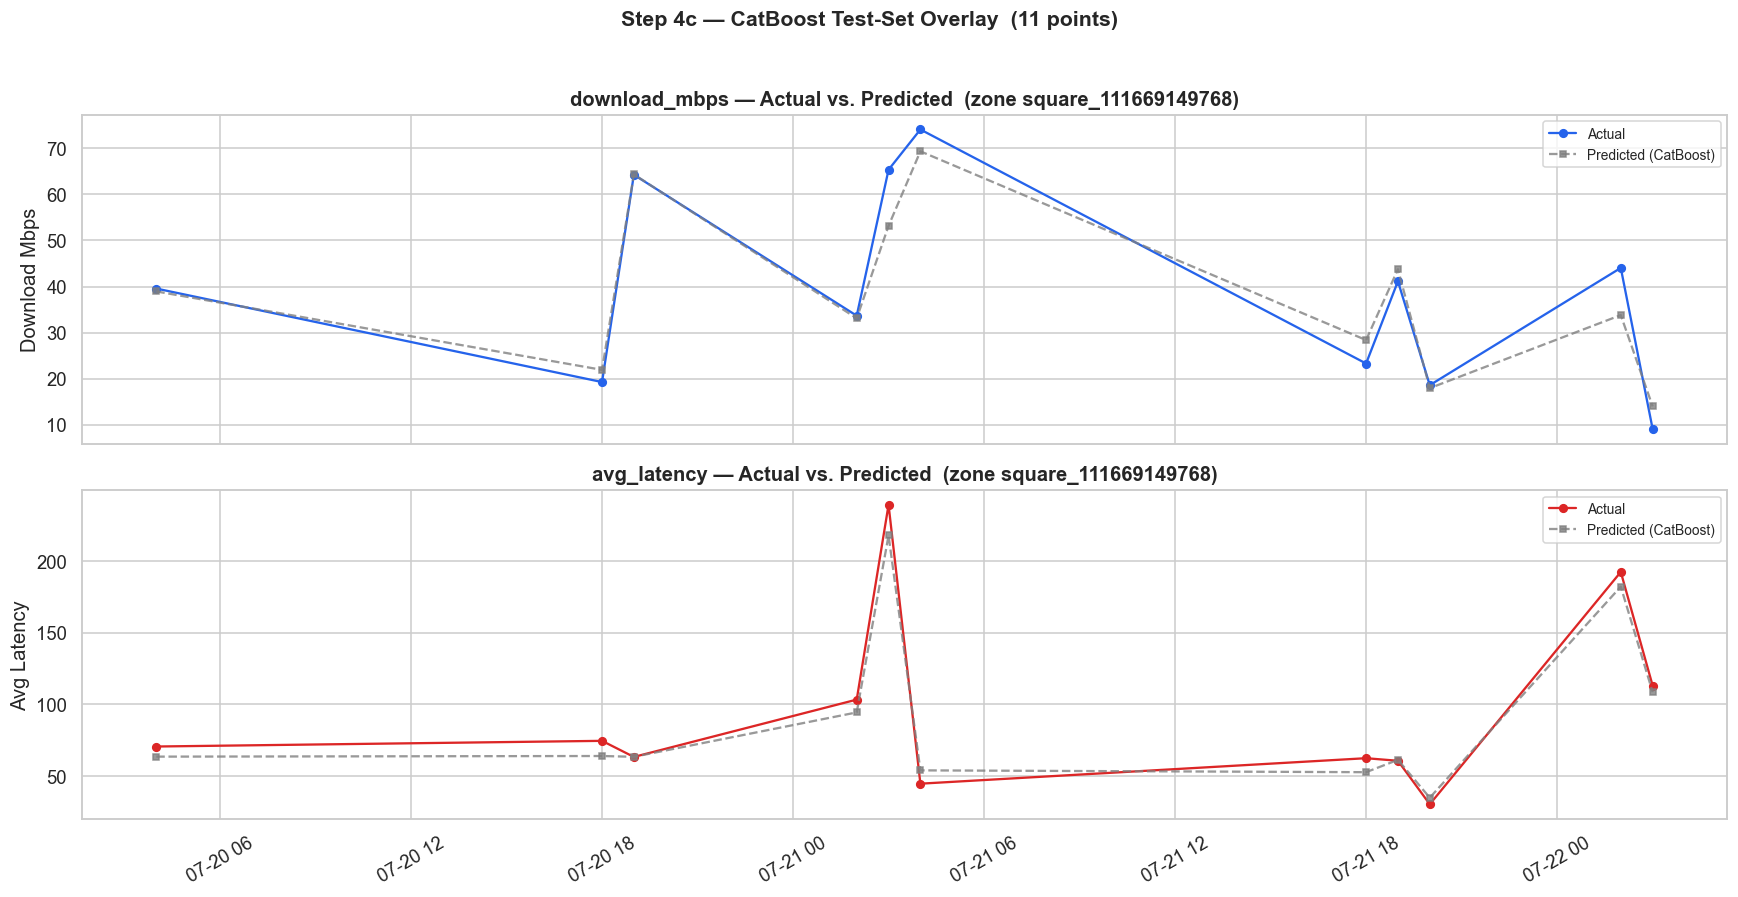

In [10]:
# ── 4c: Actual vs. Predicted overlay (winning model) ───────────
if IS_DL_WINNER:
    # Find zone with most test sequences
    zone_arr = np.array(zone_test_seq)
    unique_zones, counts = np.unique(zone_arr, return_counts=True)
    plot_zone = unique_zones[counts.argmax()]

    mask = zone_arr == plot_zone
    plot_ts     = pd.to_datetime(ts_test_seq[mask])
    plot_actual = y_test_real[mask]
    if WINNER_NAME == "LSTM":
        plot_pred = y_pred_lstm[mask]
    else:
        plot_pred = y_pred_cnn[mask]
    n_pts = int(mask.sum())
else:
    zone_counts = test_df["square_id"].value_counts()
    plot_zone   = zone_counts.idxmax()
    zone_mask   = test_df["square_id"] == plot_zone
    zone_test   = test_df[zone_mask]
    plot_ts     = zone_test["timestamp"]
    plot_actual = zone_test[TARGETS].values
    X_zone      = zone_test[TREE_FEATURES].values
    plot_pred   = np.column_stack([
        winner_model[tgt].predict(X_zone) for tgt in TARGETS
    ])
    n_pts = len(zone_test)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
colors = ["#2563eb", "#dc2626"]

for ax, i, tgt, c in zip(axes, range(2), TARGETS, colors):
    ax.plot(plot_ts, plot_actual[:, i], "o-", color=c, ms=5, lw=1.5, label="Actual")
    ax.plot(plot_ts, plot_pred[:, i],   "s--", color="grey", ms=4, lw=1.5,
            alpha=0.8, label=f"Predicted ({WINNER_NAME})")
    ax.set_ylabel(tgt.replace("_", " ").title())
    ax.set_title(f"{tgt} — Actual vs. Predicted  (zone {plot_zone})")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=30)

fig.suptitle(f"Step 4c — {WINNER_NAME} Test-Set Overlay  ({n_pts} points)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## Step 5 — 12-Hour Dashboard Forecast (Frontend Contract)

**Non-negotiable output:** `metrics/forecast_data.csv` with exactly **12 rows**:

| Column | Type |
|--------|------|
| `timestamp` | datetime (future hours) |
| `predicted_throughput` | float (Mbps, real scale) |
| `predicted_latency` | float (ms, real scale) |

### Autoregressive forecast with lag features

For each forecast step, we **autoregressively** update lag features:
- `lag1` ← previous step's prediction, `lag2` ← lag1 from previous step, etc.
- `rmean3` ← mean of last 3 predictions
- Auxiliary features (`svr1`, `jitter`, etc.) ← zone training means (stable approximation)

In [11]:
# ── 5a: Identify top zones & last timestamp ────────────────────
top_zones = agg_df["square_id"].value_counts().head(TOP_N_ZONES).index.tolist()
last_ts   = agg_df["timestamp"].max()
FORECAST_STEPS = 12

print(f"Top {TOP_N_ZONES} zones: {top_zones}")
print(f"Last known timestamp: {last_ts}")
print(f"Forecast window: +1 h … +{FORECAST_STEPS} h")

# ── Helper: column index map ──────────────────────────────────
col_idx = {c: i for i, c in enumerate(WINDOW_COLS)}

def build_forecast_row(
    ts: pd.Timestamp,
    zone: str,
    recent_dl: list[float],
    recent_lat: list[float],
    recent_ul: list[float],
    zone_aux: dict[str, float],
) -> np.ndarray:
    """Build a single WINDOW_COLS row (unscaled) for the next forecast step.

    recent_dl / recent_lat / recent_ul: lists of recent values (most recent last),
    at least LAG_STEPS elements long.
    """
    h   = ts.hour
    dow = ts.dayofweek
    row = np.zeros(len(WINDOW_COLS))

    # Temporal
    row[col_idx["hour_sin"]]   = np.sin(2 * np.pi * h / 24)
    row[col_idx["hour_cos"]]   = np.cos(2 * np.pi * h / 24)
    row[col_idx["is_weekend"]] = int(dow >= 5)

    # Zone encoding
    row[col_idx["zone_mean_dl"]]  = zone_enc_dl.get(zone, global_mean_dl)
    row[col_idx["zone_mean_lat"]] = zone_enc_lat.get(zone, global_mean_lat)

    # Lag features (most recent value = lag1)
    for lag in range(1, LAG_STEPS + 1):
        row[col_idx[f"download_mbps_lag{lag}"]] = recent_dl[-lag]
        row[col_idx[f"avg_latency_lag{lag}"]]   = recent_lat[-lag]
        row[col_idx[f"upload_lag{lag}"]]         = recent_ul[-lag]

    # Rolling mean (last 3 values before current step)
    row[col_idx["download_mbps_rmean3"]] = np.mean(recent_dl[-3:])
    row[col_idx["avg_latency_rmean3"]]   = np.mean(recent_lat[-3:])

    # Auxiliary features (zone training means)
    for c in AUX_COLS:
        row[col_idx[c]] = zone_aux[c]

    # Current targets (filled with last predicted values)
    row[col_idx["download_mbps"]] = recent_dl[-1]
    row[col_idx["avg_latency"]]   = recent_lat[-1]

    return row

# ── 5b: Generate 12-hour forecasts per zone ────────────────────
all_zone_preds: list[pd.DataFrame] = []

for zone in top_zones:
    zone_data = agg_df[agg_df["square_id"] == zone].sort_values("timestamp")
    zone_data_scaled = agg_scaled[agg_scaled["square_id"] == zone].sort_values("timestamp")

    if len(zone_data) < max(SEQ_LEN, LAG_STEPS):
        continue

    # Last known actual target values (for lag initialisation)
    hist_dl  = zone_data["download_mbps"].values[-max(SEQ_LEN, LAG_STEPS):].tolist()
    hist_lat = zone_data["avg_latency"].values[-max(SEQ_LEN, LAG_STEPS):].tolist()
    # Upload proxy history: use actual zone data where available, else zone mean
    if "upload_mbps_lag1" in zone_data.columns:
        hist_ul = zone_data["upload_mbps_lag1"].values[-max(SEQ_LEN, LAG_STEPS):].tolist()
    else:
        ul_mean = float(zone_aux_means["upload_mbps_lag1"].get(zone, agg_df["upload_mbps_lag1"].mean()))
        hist_ul = [ul_mean] * max(SEQ_LEN, LAG_STEPS)

    # Zone auxiliary means for forecast
    zone_aux = {c: float(zone_aux_means[c].get(zone, agg_df[c].mean())) for c in AUX_COLS}

    if IS_DL_WINNER:
        # Rolling DL forecast: feed last window → predict → slide
        window = zone_data_scaled[WINDOW_COLS].values[-SEQ_LEN:]
        preds_real = []
        ts = last_ts

        for _ in range(FORECAST_STEPS):
            pred_scaled = winner_model.predict(window[np.newaxis], verbose=0)[0]
            pred_real   = pred_scaled * target_range + target_min
            pred_real   = np.clip(pred_real, 0, None)
            preds_real.append(pred_real)

            hist_dl.append(float(pred_real[0]))
            hist_lat.append(float(pred_real[1]))
            hist_ul.append(zone_aux["upload_mbps_lag1"])  # use zone mean for forecast
            ts = ts + pd.Timedelta(hours=1)

            # Build next row in original scale, then re-scale
            next_row_unscaled = build_forecast_row(ts, zone, hist_dl, hist_lat, hist_ul, zone_aux)
            next_row_scaled   = (next_row_unscaled - scaler.data_min_) / scaler.data_range_
            next_row_scaled   = np.clip(next_row_scaled, 0, 1)

            window = np.vstack([window[1:], next_row_scaled[np.newaxis]])

        zone_forecast = pd.DataFrame(preds_real, columns=TARGETS)
    else:
        # Tree-based: autoregressive multi-step prediction with lag features
        preds = []
        for step in range(FORECAST_STEPS):
            ts = last_ts + pd.Timedelta(hours=step + 1)
            feat_row = build_forecast_row(ts, zone, hist_dl, hist_lat, hist_ul, zone_aux)
            X_row = np.array([[feat_row[col_idx[f]] for f in TREE_FEATURES]])
            pred_pair = np.array([
                float(np.clip(winner_model[tgt].predict(X_row)[0], 0, None))
                for tgt in TARGETS
            ])
            preds.append(pred_pair)
            hist_dl.append(pred_pair[0])
            hist_lat.append(pred_pair[1])
            hist_ul.append(zone_aux["upload_mbps_lag1"])  # zone mean for forecast

        zone_forecast = pd.DataFrame(preds, columns=TARGETS)

    zone_forecast["timestamp"] = pd.date_range(
        start=last_ts + pd.Timedelta(hours=1), periods=FORECAST_STEPS, freq="h"
    )
    all_zone_preds.append(zone_forecast)

# ── 5c: Aggregate across zones → exactly 12 rows ──────────────
future_all = pd.concat(all_zone_preds, ignore_index=True)
forecast_export = (
    future_all
    .groupby("timestamp")[TARGETS]
    .mean()
    .reset_index()
    .rename(columns={"download_mbps": "predicted_throughput",
                      "avg_latency": "predicted_latency"})
)

out_path = METRICS_DIR / "forecast_data.csv"
forecast_export.to_csv(out_path, index=False)
print(f"✅ Exported {len(forecast_export)} rows → {out_path}")
print(f"   Schema: {forecast_export.columns.tolist()}")
forecast_export.round(2)

Top 5 zones: ['square_68719476752', 'square_60129542192', 'square_51539607566', 'square_111669149768', 'square_51539607626']
Last known timestamp: 2022-07-22 03:00:00
Forecast window: +1 h … +12 h
✅ Exported 12 rows → metrics\forecast_data.csv
   Schema: ['timestamp', 'predicted_throughput', 'predicted_latency']


,timestamp,predicted_throughput,predicted_latency
0,2022-07-22 04:00:00,29.33,77.59
1,2022-07-22 05:00:00,28.64,75.79
2,2022-07-22 06:00:00,27.59,78.54
3,2022-07-22 07:00:00,27.19,81.17
4,2022-07-22 08:00:00,27.20,81.17
5,2022-07-22 09:00:00,27.36,81.24
6,2022-07-22 10:00:00,27.19,81.38
7,2022-07-22 11:00:00,27.87,81.19
8,2022-07-22 12:00:00,28.53,81.18
9,2022-07-22 13:00:00,28.71,81.19


In [12]:
# ── 5d: Save winning model + supporting artifacts ──────────────

if IS_DL_WINNER:
    model_path = MODELS_DIR / "forecasting_model.h5"
    winner_model.save(model_path)
    print(f"💾 Saved Keras model → {model_path}")
else:
    prefix = WINNER_NAME.lower()   # "xgboost" or "catboost"
    for tgt in TARGETS:
        p = MODELS_DIR / f"{prefix}_{tgt}.pkl"
        joblib.dump(winner_model[tgt], p)
        print(f"💾 Saved: {p}")

# Save scaler + encoding artifacts for backend inference
enc_artifact = {
    "scaler": scaler,
    "zone_enc_dl": zone_enc_dl.to_dict(),
    "zone_enc_lat": zone_enc_lat.to_dict(),
    "zone_aux_means": {c: zone_aux_means[c].to_dict() for c in AUX_COLS},
    "global_mean_dl": float(global_mean_dl),
    "global_mean_lat": float(global_mean_lat),
    "target_min": target_min.tolist(),
    "target_range": target_range.tolist(),
    "window_cols": WINDOW_COLS,
    "tree_features": TREE_FEATURES,
    "targets": TARGETS,
    "aux_cols": AUX_COLS,
    "lag_steps": LAG_STEPS,
    "seq_len": SEQ_LEN,
    "top_zones": top_zones,
    "winner": WINNER_NAME,
    "is_dl": IS_DL_WINNER,
}
joblib.dump(enc_artifact, MODELS_DIR / "pipeline_config.pkl")
print(f"💾 Saved: {MODELS_DIR / 'pipeline_config.pkl'}")
print("\n✅ All model artifacts saved.")

💾 Saved: models\catboost_download_mbps.pkl
💾 Saved: models\catboost_avg_latency.pkl
💾 Saved: models\pipeline_config.pkl

✅ All model artifacts saved.


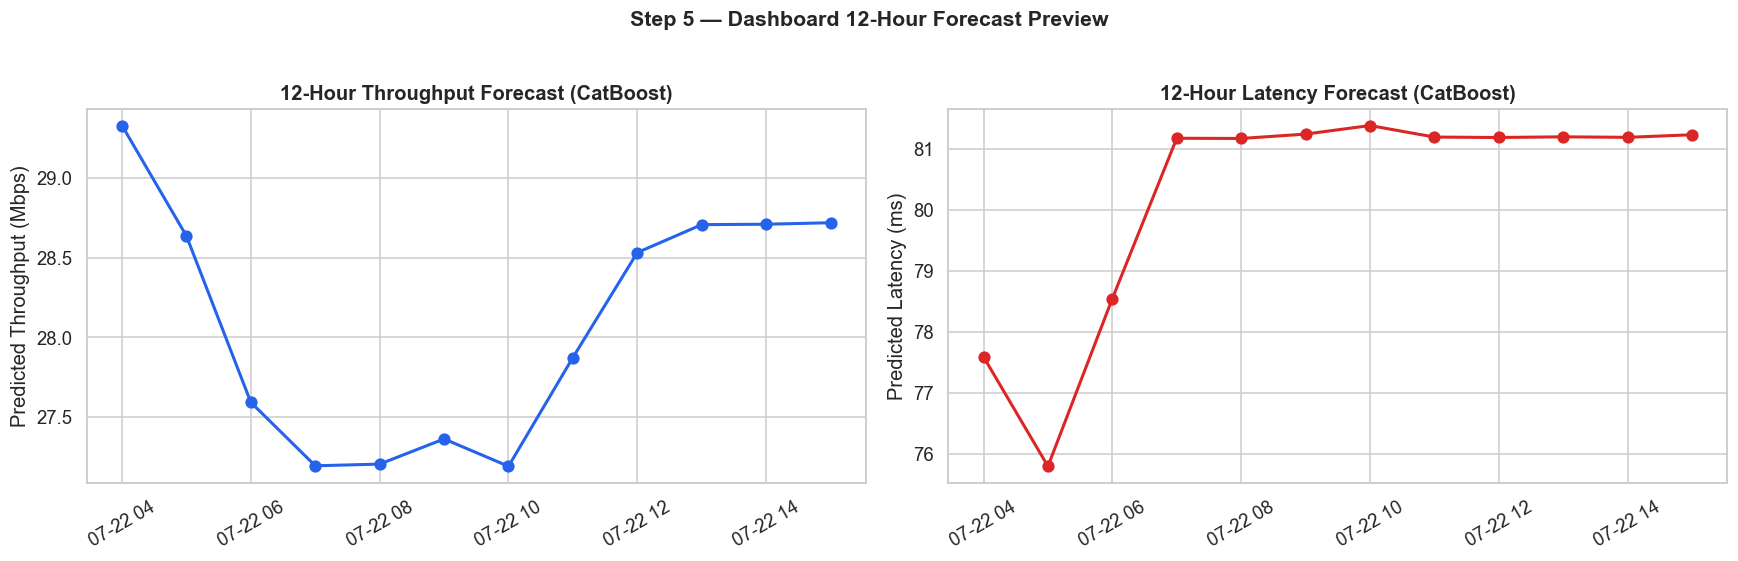


✅ Verification passed: 12 rows, columns ['timestamp', 'predicted_throughput', 'predicted_latency']
   Winner: CatBoost  |  DL model: False
   This is exactly what the frontend renders via /api/forecast-data


In [13]:
# ── 5e: Visualize the 12-hour dashboard forecast ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(forecast_export["timestamp"], forecast_export["predicted_throughput"],
        "o-", color="#2563eb", lw=2, ms=7)
ax.set_ylabel("Predicted Throughput (Mbps)")
ax.set_title(f"12-Hour Throughput Forecast ({WINNER_NAME})")
ax.tick_params(axis="x", rotation=30)

ax = axes[1]
ax.plot(forecast_export["timestamp"], forecast_export["predicted_latency"],
        "o-", color="#dc2626", lw=2, ms=7)
ax.set_ylabel("Predicted Latency (ms)")
ax.set_title(f"12-Hour Latency Forecast ({WINNER_NAME})")
ax.tick_params(axis="x", rotation=30)

fig.suptitle("Step 5 — Dashboard 12-Hour Forecast Preview",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Final verification ──────────────────────────────────────────
check = pd.read_csv(out_path)
assert len(check) == 12, f"Expected 12 rows, got {len(check)}"
assert set(check.columns) == {"timestamp", "predicted_throughput", "predicted_latency"}
print(f"\n✅ Verification passed: {len(check)} rows, columns {list(check.columns)}")
print(f"   Winner: {WINNER_NAME}  |  DL model: {IS_DL_WINNER}")
print("   This is exactly what the frontend renders via /api/forecast-data")